##  Survival Analysis by Gender

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv("../data/raw/train.csv")

gender_survival = train_df.groupby("Sex")["Survived"].mean()
gender_survival

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

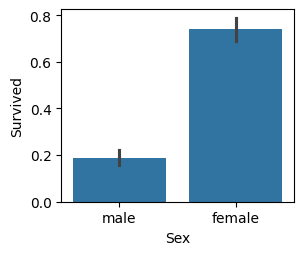

In [2]:
plt.figure(figsize=(3,2.5))
sns.barplot(x="Sex", y="Survived", data=train_df)
plt.show()

### Interpretation

- Female survival rate is significantly higher (~74%)
- Male survival rate is very low (~19%)
- Gender is a strong predictor of survival
- This supports the "women first" rescue policy

## Survival by Passenger Class

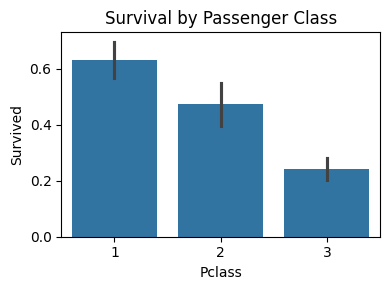

In [3]:
plt.figure(figsize=(4,3))
sns.barplot(x="Pclass", y="Survived", data=train_df)
plt.title("Survival by Passenger Class")
plt.tight_layout()
plt.show()

### Interpretation

- Survival rate decreases as passenger class decreases.
- 1st class passengers had the highest survival (~63%).
- 3rd class passengers had the lowest survival (~24%).
- This suggests economic or social class bias in rescue priority.
- Pclass is a strong predictive feature.

## Survival by Age

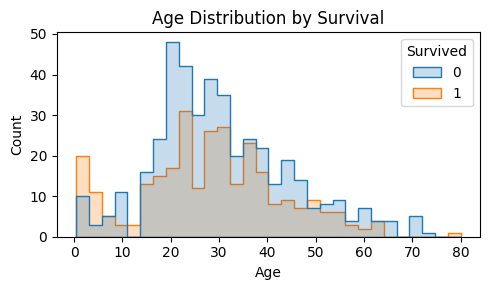

In [4]:
plt.figure(figsize=(5,3))

sns.histplot(data=train_df, x="Age", hue="Survived",bins=30, kde=False, element="step")

plt.title("Age Distribution by Survival")
plt.tight_layout()
plt.show()

### Interpretation

- Children (age < 10) show relatively higher survival.
- Adults (20–40) had lower survival rates.
- Elderly passengers had low survival.
- Age interacts strongly with gender and class.

## Survival by Fare

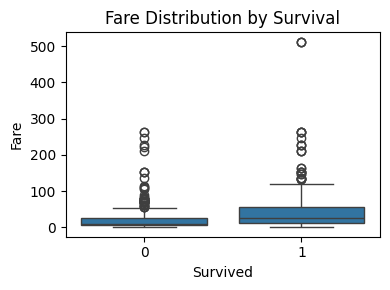

In [5]:
plt.figure(figsize=(4,3))
sns.boxplot(x="Survived", y="Fare", data=train_df)
plt.title("Fare Distribution by Survival")
plt.tight_layout()
plt.show()

### Interpretation

- Survivors generally paid higher fares.
- Higher fare passengers had better survival probability.
- Fare distribution is heavily right-skewed.
- Wealth appears to influence rescue priority.

## Survival by Family Size

In [6]:
train_df["FamilySize"] = train_df["SibSp"] + train_df["Parch"] + 1

train_df["FamilySize"].head()

0    2
1    2
2    1
3    2
4    1
Name: FamilySize, dtype: int64

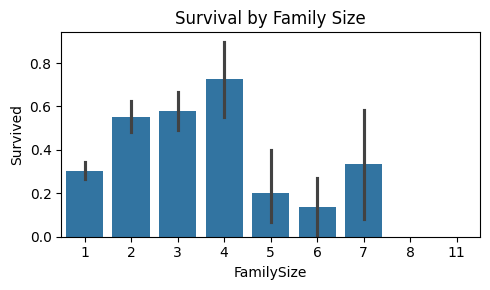

In [7]:
plt.figure(figsize=(5,3))
sns.barplot(x="FamilySize", y="Survived", data=train_df)
plt.title("Survival by Family Size")
plt.tight_layout()
plt.show()

### Interpretation

- Passengers traveling alone had lower survival.
- Small families (2–4 members) had the highest survival.
- Large families (5+) had very low survival.
- FamilySize has a non-linear relationship with survival.

## Correlation Analysis


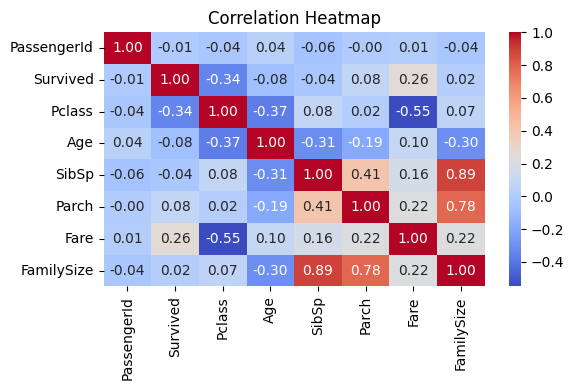

In [8]:
plt.figure(figsize=(6,4))

numeric_cols = train_df.select_dtypes(include=["int64", "float64"])

corr = numeric_cols.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Interpretation

- Pclass has strong negative correlation with survival (-0.34).
- Fare has positive correlation with survival (0.26).
- FamilySize shows weak linear correlation but earlier plots showed non-linear behavior.
- Fare and Pclass are strongly correlated (-0.55).
- FamilySize is highly correlated with SibSp and Parch.